# Prétraitement du Dataset Diabète

Ce notebook couvre les étapes de prétraitement du jeu de données sur le risque diabétique :
1. Chargement et nettoyage des données
2. Identification et traitement des valeurs manquantes
3. Détection et gestion des outliers (IQR + Z-score)
4. Étude des relations entre variables (corrélation)
5. Sélection des variables avec la plus grande variabilité
6. Visualisation (pairplot)
7. Normalisation / Standardisation

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


df=pd.read_csv("../data/dataset-diabete.csv")

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## 2. Chargement et nettoyage initial du dataset

In [ ]:
df = pd.read_csv("../data/dataset-diabete.csv")
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Colonne 'Unnamed: 0' supprimée")

print(f"\nDimensions du dataset : {df.shape}")
print(f"\nAperçu des premières lignes :")
display(df.head())
print(f"\nTypes des colonnes :")
print(df.dtypes)
print(f"\nStatistiques descriptives :")
display(df.describe())

Colonne 'Unnamed: 0' supprimée

Dimensions du dataset : (768, 8)

Aperçu des premières lignes :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



Types des colonnes :
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object

Statistiques descriptives :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


## 3. Identification et traitement des valeurs manquantes

Dans ce dataset (Pima Indians Diabetes), les colonnes `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` et `BMI` contiennent des valeurs `0` qui représentent en réalité des valeurs manquantes (ces mesures ne peuvent pas être égales à 0 biologiquement).

Nous les remplaçons par `NaN` puis nous utilisons l'imputation KNN pour les combler.

VALEURS MANQUANTES AVANT IMPUTATION
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Total de valeurs manquantes : 652


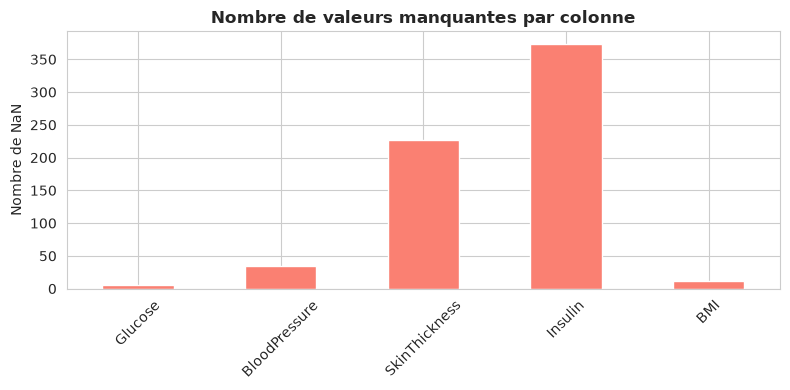

In [ ]:

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)
print("=" * 50)
print("VALEURS MANQUANTES AVANT IMPUTATION")
print("=" * 50)
missing_before = df[zero_cols].isnull().sum()
print(missing_before)
print(f"\nTotal de valeurs manquantes : {missing_before.sum()}")
fig, ax = plt.subplots(figsize=(8, 4))
missing_before.plot(kind='bar', color='salmon', ax=ax)
ax.set_title("Nombre de valeurs manquantes par colonne", fontweight='bold')
ax.set_ylabel("Nombre de NaN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.1 Imputation par KNN

L'imputation KNN (k=5) remplace chaque valeur manquante par la moyenne pondérée des 5 plus proches voisins. On standardise temporairement les données pour que la distance KNN soit cohérente entre les variables d'échelles différentes.

In [ ]:

scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(df[zero_cols])
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = imputer.fit_transform(X_scaled)
X_imputed = scaler_temp.inverse_transform(X_imputed_scaled)
df[zero_cols] = X_imputed
print("=" * 50)
print("VALEURS MANQUANTES APRÈS IMPUTATION")
print("=" * 50)
missing_after = df.isnull().sum()
print(missing_after)
print(f"\nTotal de valeurs manquantes : {missing_after.sum()}")
print("\nToutes les valeurs manquantes ont été imputées avec succès.")

VALEURS MANQUANTES APRÈS IMPUTATION
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Total de valeurs manquantes : 0

Toutes les valeurs manquantes ont été imputées avec succès.


## 4. Détection des outliers

### 4.1 Méthode IQR (Interquartile Range) + Boîtes à moustaches

Un outlier est défini comme une valeur en dehors de l'intervalle `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

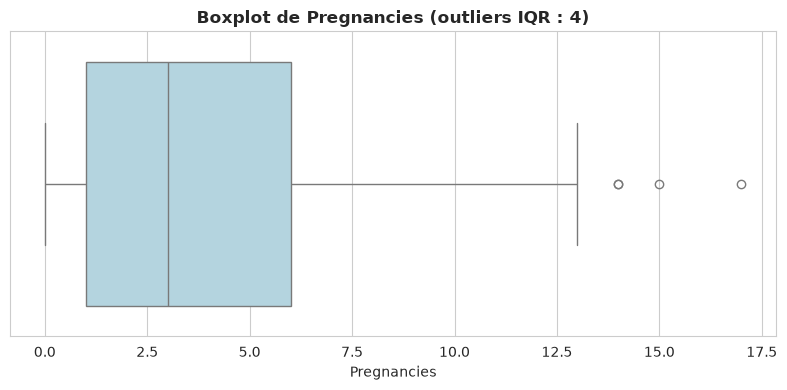


===== Pregnancies =====
Q1 : 1.0
Q3 : 6.0
IQR : 5.0
Borne inférieure : -6.5
Borne supérieure : 13.5
Nombre d'outliers : 4 (0.5%)
Valeurs outliers : [15 17 14 14]



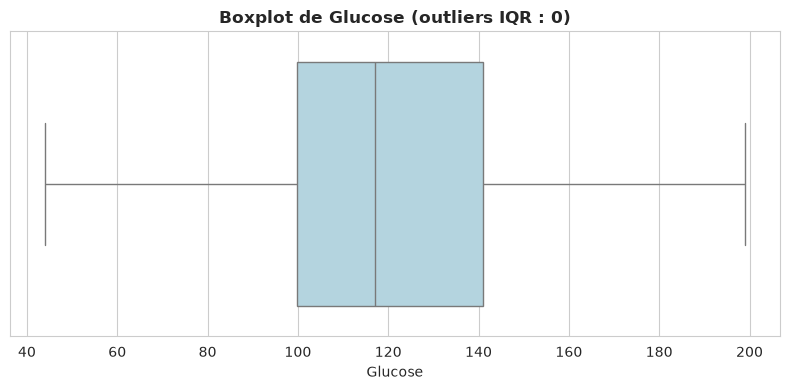


===== Glucose =====
Q1 : 99.75
Q3 : 141.0
IQR : 41.25
Borne inférieure : 37.875
Borne supérieure : 202.875
Nombre d'outliers : 0 (0.0%)



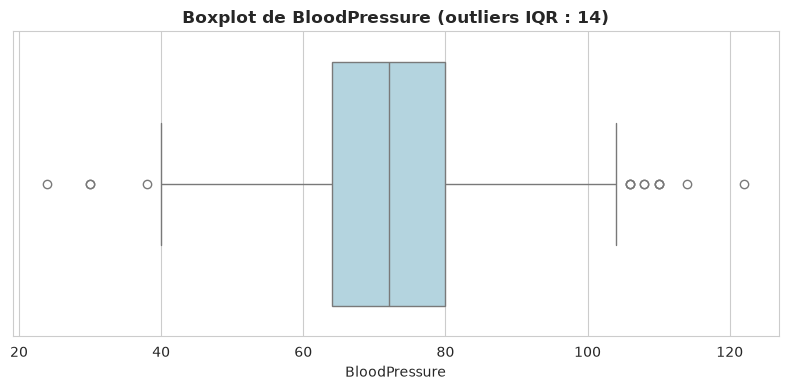


===== BloodPressure =====
Q1 : 64.0
Q3 : 80.0
IQR : 16.0
Borne inférieure : 40.0
Borne supérieure : 104.0
Nombre d'outliers : 14 (1.8%)
Valeurs outliers : [ 30. 110. 108. 122.  30. 110. 108. 110.  24.  38. 106. 106. 106. 114.]



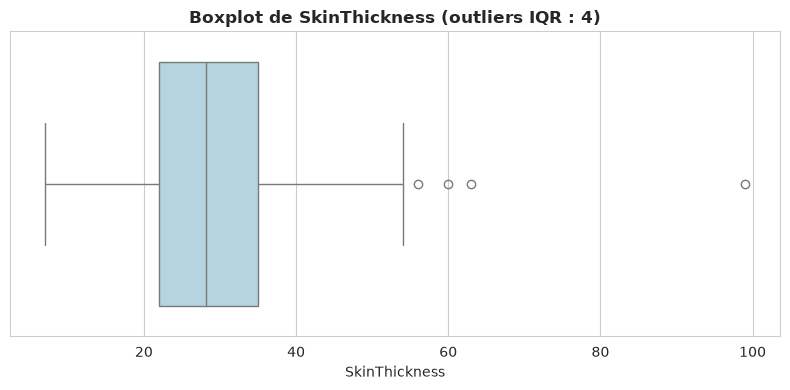


===== SkinThickness =====
Q1 : 22.0
Q3 : 35.0
IQR : 13.0
Borne inférieure : 2.5
Borne supérieure : 54.5
Nombre d'outliers : 4 (0.5%)
Valeurs outliers : [60. 56. 63. 99.]



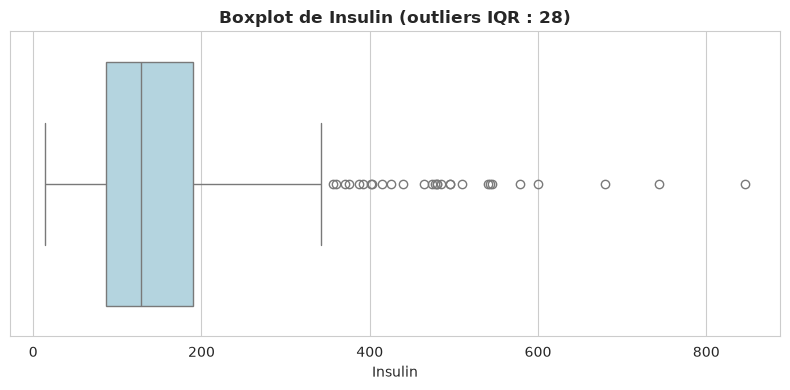


===== Insulin =====
Q1 : 87.0
Q3 : 189.85000000000002
IQR : 102.85000000000002
Borne inférieure : -67.27500000000003
Borne supérieure : 344.12500000000006
Nombre d'outliers : 28 (3.6%)



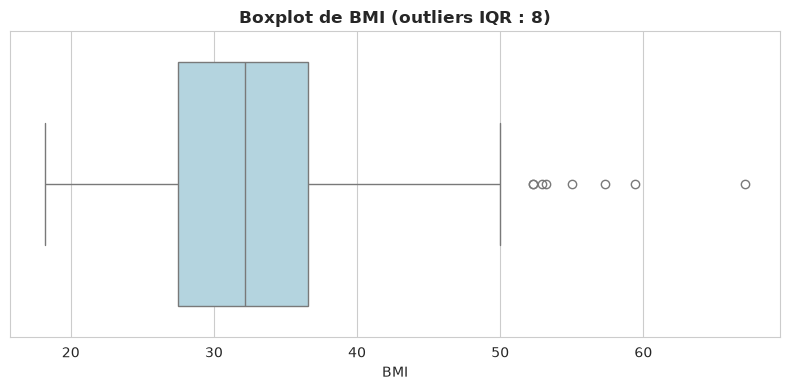


===== BMI =====
Q1 : 27.5
Q3 : 36.6
IQR : 9.100000000000001
Borne inférieure : 13.849999999999998
Borne supérieure : 50.25
Nombre d'outliers : 8 (1.0%)
Valeurs outliers : [53.2 55.  67.1 52.3 52.3 52.9 59.4 57.3]



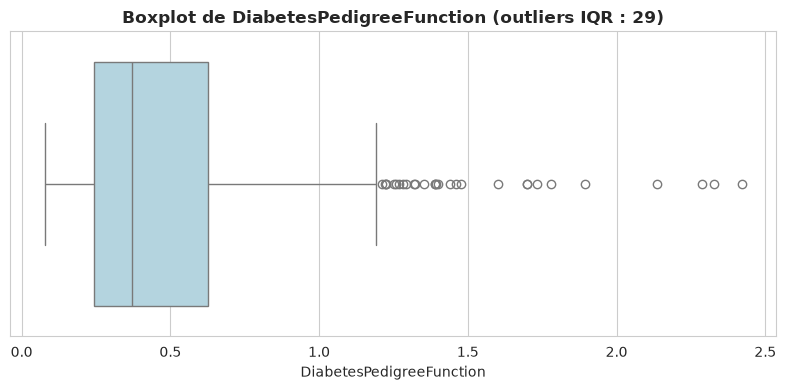


===== DiabetesPedigreeFunction =====
Q1 : 0.24375
Q3 : 0.62625
IQR : 0.38249999999999995
Borne inférieure : -0.32999999999999996
Borne supérieure : 1.2
Nombre d'outliers : 29 (3.8%)



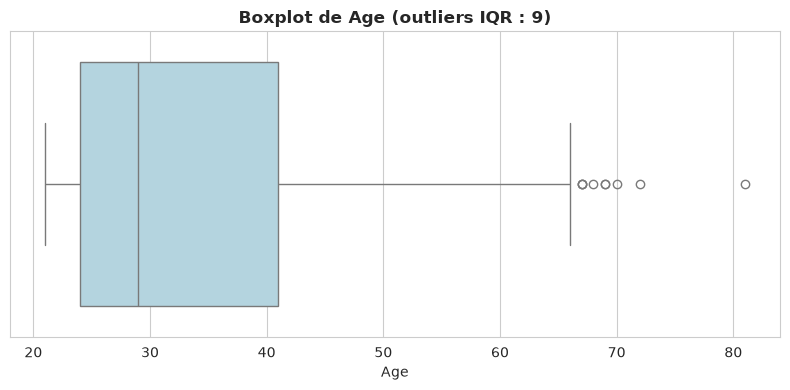


===== Age =====
Q1 : 24.0
Q3 : 41.0
IQR : 17.0
Borne inférieure : -1.5
Borne supérieure : 66.5
Nombre d'outliers : 9 (1.2%)
Valeurs outliers : [69 67 72 81 67 67 70 68 69]


RÉSUMÉ DES OUTLIERS (IQR)


,Nb_outliers,Pct_outliers
Pregnancies,4.0,0.5
Glucose,0.0,0.0
BloodPressure,14.0,1.8
SkinThickness,4.0,0.5
Insulin,28.0,3.6
BMI,8.0,1.0
DiabetesPedigreeFunction,29.0,3.8
Age,9.0,1.2


In [ ]:

numeric_cols = df.select_dtypes(include='number').columns.tolist()

outlier_summary_iqr = {}

for c in numeric_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_mask = (df[c] < lower) | (df[c] > upper)
    n_outliers = outliers_mask.sum()
    outlier_summary_iqr[c] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower': lower, 'Upper': upper,
        'Nb_outliers': n_outliers,
        'Pct_outliers': round(n_outliers / len(df) * 100, 1)
    }

    # Boxplot
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df, x=c, ax=ax, color='lightblue')
    ax.set_title(f"Boxplot de {c} (outliers IQR : {n_outliers})", fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n===== {c} =====")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Borne inférieure : {lower}")
    print(f"Borne supérieure : {upper}")
    print(f"Nombre d'outliers : {n_outliers} ({round(n_outliers / len(df) * 100, 1)}%)")
    if n_outliers > 0 and n_outliers <= 20:
        print(f"Valeurs outliers : {df.loc[outliers_mask, c].values}")
    print()

# Résumé global
print("\n" + "=" * 60)
print("RÉSUMÉ DES OUTLIERS (IQR)")
print("=" * 60)
summary_df = pd.DataFrame(outlier_summary_iqr).T
display(summary_df[['Nb_outliers', 'Pct_outliers']])


### 4.3 Gestion des outliers

Plutôt que de supprimer les lignes contenant des outliers (ce qui pourrait réduire significativement le dataset), nous utilisons la technique du **clipping (winsorisation)** : les valeurs en dehors des bornes IQR sont ramenées aux bornes.

Cette approche conserve toutes les observations tout en limitant l'influence des valeurs extrêmes.

In [ ]:
print("Dimensions avant traitement des outliers :", df.shape)
for c in numeric_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_clipped = ((df[c] < lower) | (df[c] > upper)).sum()
    if n_clipped > 0:
        df[c] = df[c].clip(lower=lower, upper=upper)
        print(f"{c} : {n_clipped} valeurs clippées à [{lower:.2f}, {upper:.2f}]")

print(f"\nDimensions après traitement des outliers : {df.shape}")
print("Aucune ligne supprimée — les valeurs extrêmes ont été ramenées aux bornes IQR.")

# Vérification : plus d'outliers
print("\n--- Vérification post-traitement ---")
for c in numeric_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_remaining = ((df[c] < lower) | (df[c] > upper)).sum()
    print(f"{c} : {n_remaining} outliers restants")

Dimensions avant traitement des outliers : (768, 8)
Pregnancies : 4 valeurs clippées à [-6.50, 13.50]
BloodPressure : 14 valeurs clippées à [40.00, 104.00]
SkinThickness : 4 valeurs clippées à [2.50, 54.50]
Insulin : 28 valeurs clippées à [-67.28, 344.13]
BMI : 8 valeurs clippées à [13.85, 50.25]
DiabetesPedigreeFunction : 29 valeurs clippées à [-0.33, 1.20]
Age : 9 valeurs clippées à [-1.50, 66.50]

Dimensions après traitement des outliers : (768, 8)
Aucune ligne supprimée — les valeurs extrêmes ont été ramenées aux bornes IQR.

--- Vérification post-traitement ---
Pregnancies : 0 outliers restants
Glucose : 0 outliers restants
BloodPressure : 0 outliers restants
SkinThickness : 0 outliers restants
Insulin : 0 outliers restants
BMI : 0 outliers restants
DiabetesPedigreeFunction : 0 outliers restants
Age : 0 outliers restants


## 5. Étude des relations entre les variables

### 5.1 Matrice de corrélation

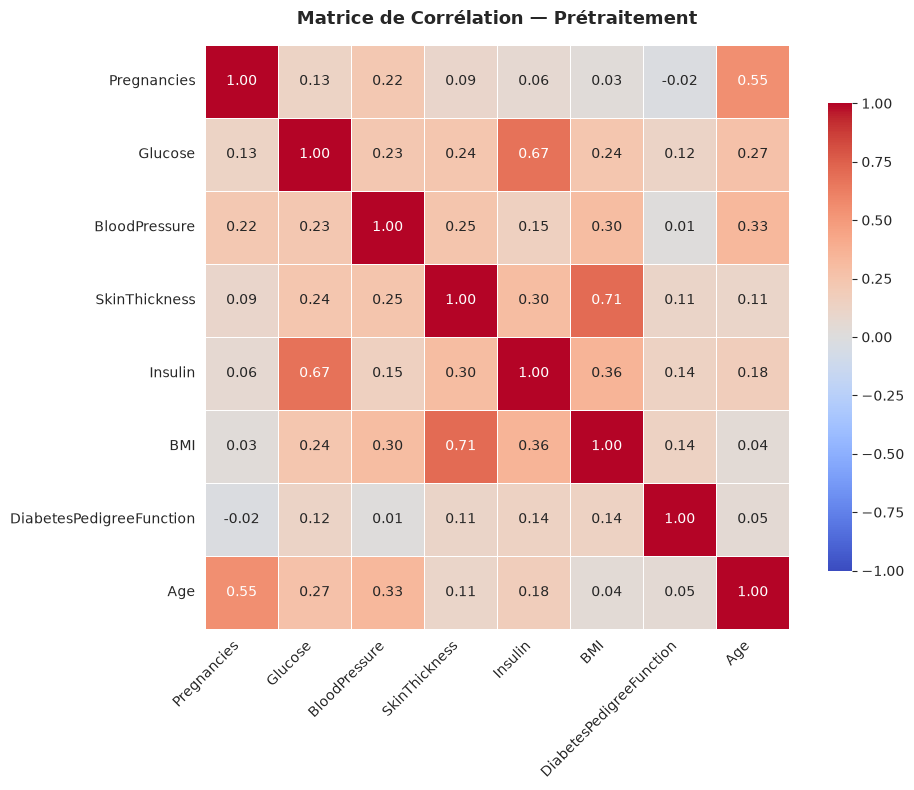


Corrélations les plus fortes (|r| > 0.3) :
  Pregnancies ↔ Age : r = 0.550
  Glucose ↔ Insulin : r = 0.673
  BloodPressure ↔ Age : r = 0.334
  SkinThickness ↔ Insulin : r = 0.302
  SkinThickness ↔ BMI : r = 0.708
  Insulin ↔ BMI : r = 0.358


In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    square=True
)
plt.title("Matrice de Corrélation — Prétraitement", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("\nCorrélations les plus fortes (|r| > 0.3) :")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]} : r = {r:.3f}")

## 6. Sélection des variables avec la plus grande variabilité

On utilise l'écart-type (standard deviation) pour mesurer la variabilité de chaque variable numérique.

Variabilité (écart-type) de chaque variable :


Insulin                     78.104767
Glucose                     30.454597
BloodPressure               11.829153
Age                         11.628404
SkinThickness                9.197377
BMI                          6.685068
Pregnancies                  3.344157
DiabetesPedigreeFunction     0.285596
dtype: float64

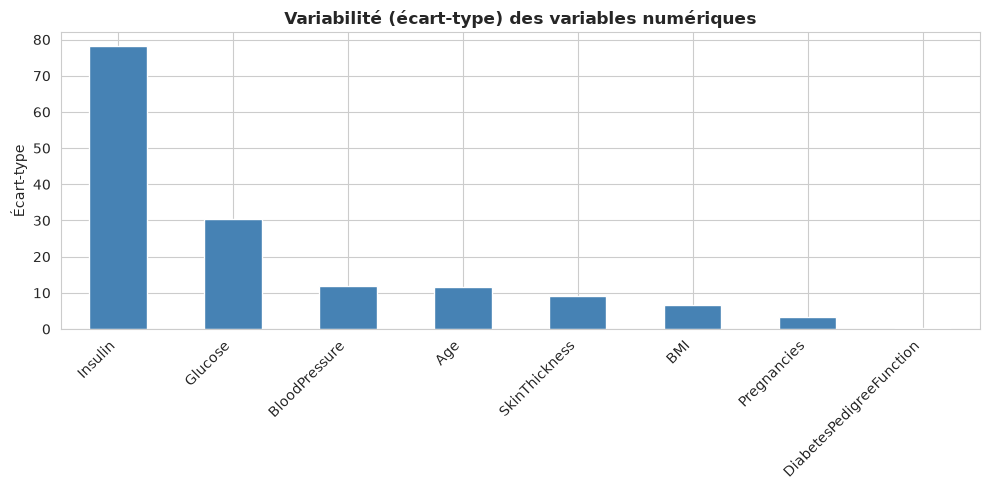


Variables avec la plus grande variabilité : ['Insulin', 'Glucose']


In [ ]:
variabilite = (
    df.select_dtypes(include='number')
      .std()
      .sort_values(ascending=False)
)

print("Variabilité (écart-type) de chaque variable :")
display(variabilite)
fig, ax = plt.subplots(figsize=(10, 5))
variabilite.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title("Variabilité (écart-type) des variables numériques", fontweight='bold')
ax.set_ylabel("Écart-type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
top_variables = variabilite.head(2).index.tolist()
print(f"\nVariables avec la plus grande variabilité : {top_variables}")

## 7. Visualisation des relations entre variables (Pairplot)

Le pairplot montre les distributions univariées (diagonale) et les relations bivariées (hors diagonale) entre les variables sélectionnées.

Pairplot des variables les plus variables : ['Insulin', 'Glucose']


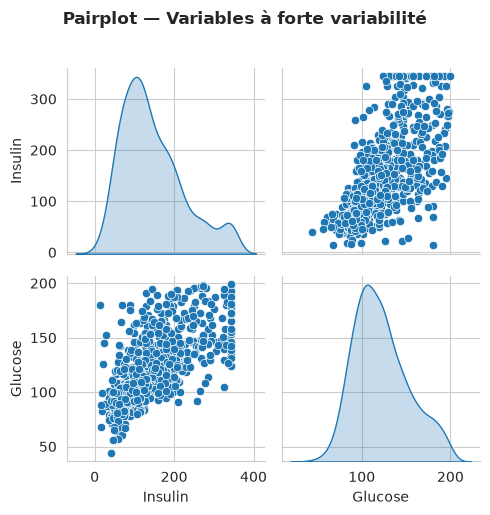


Pairplot complet (toutes les variables numériques) :


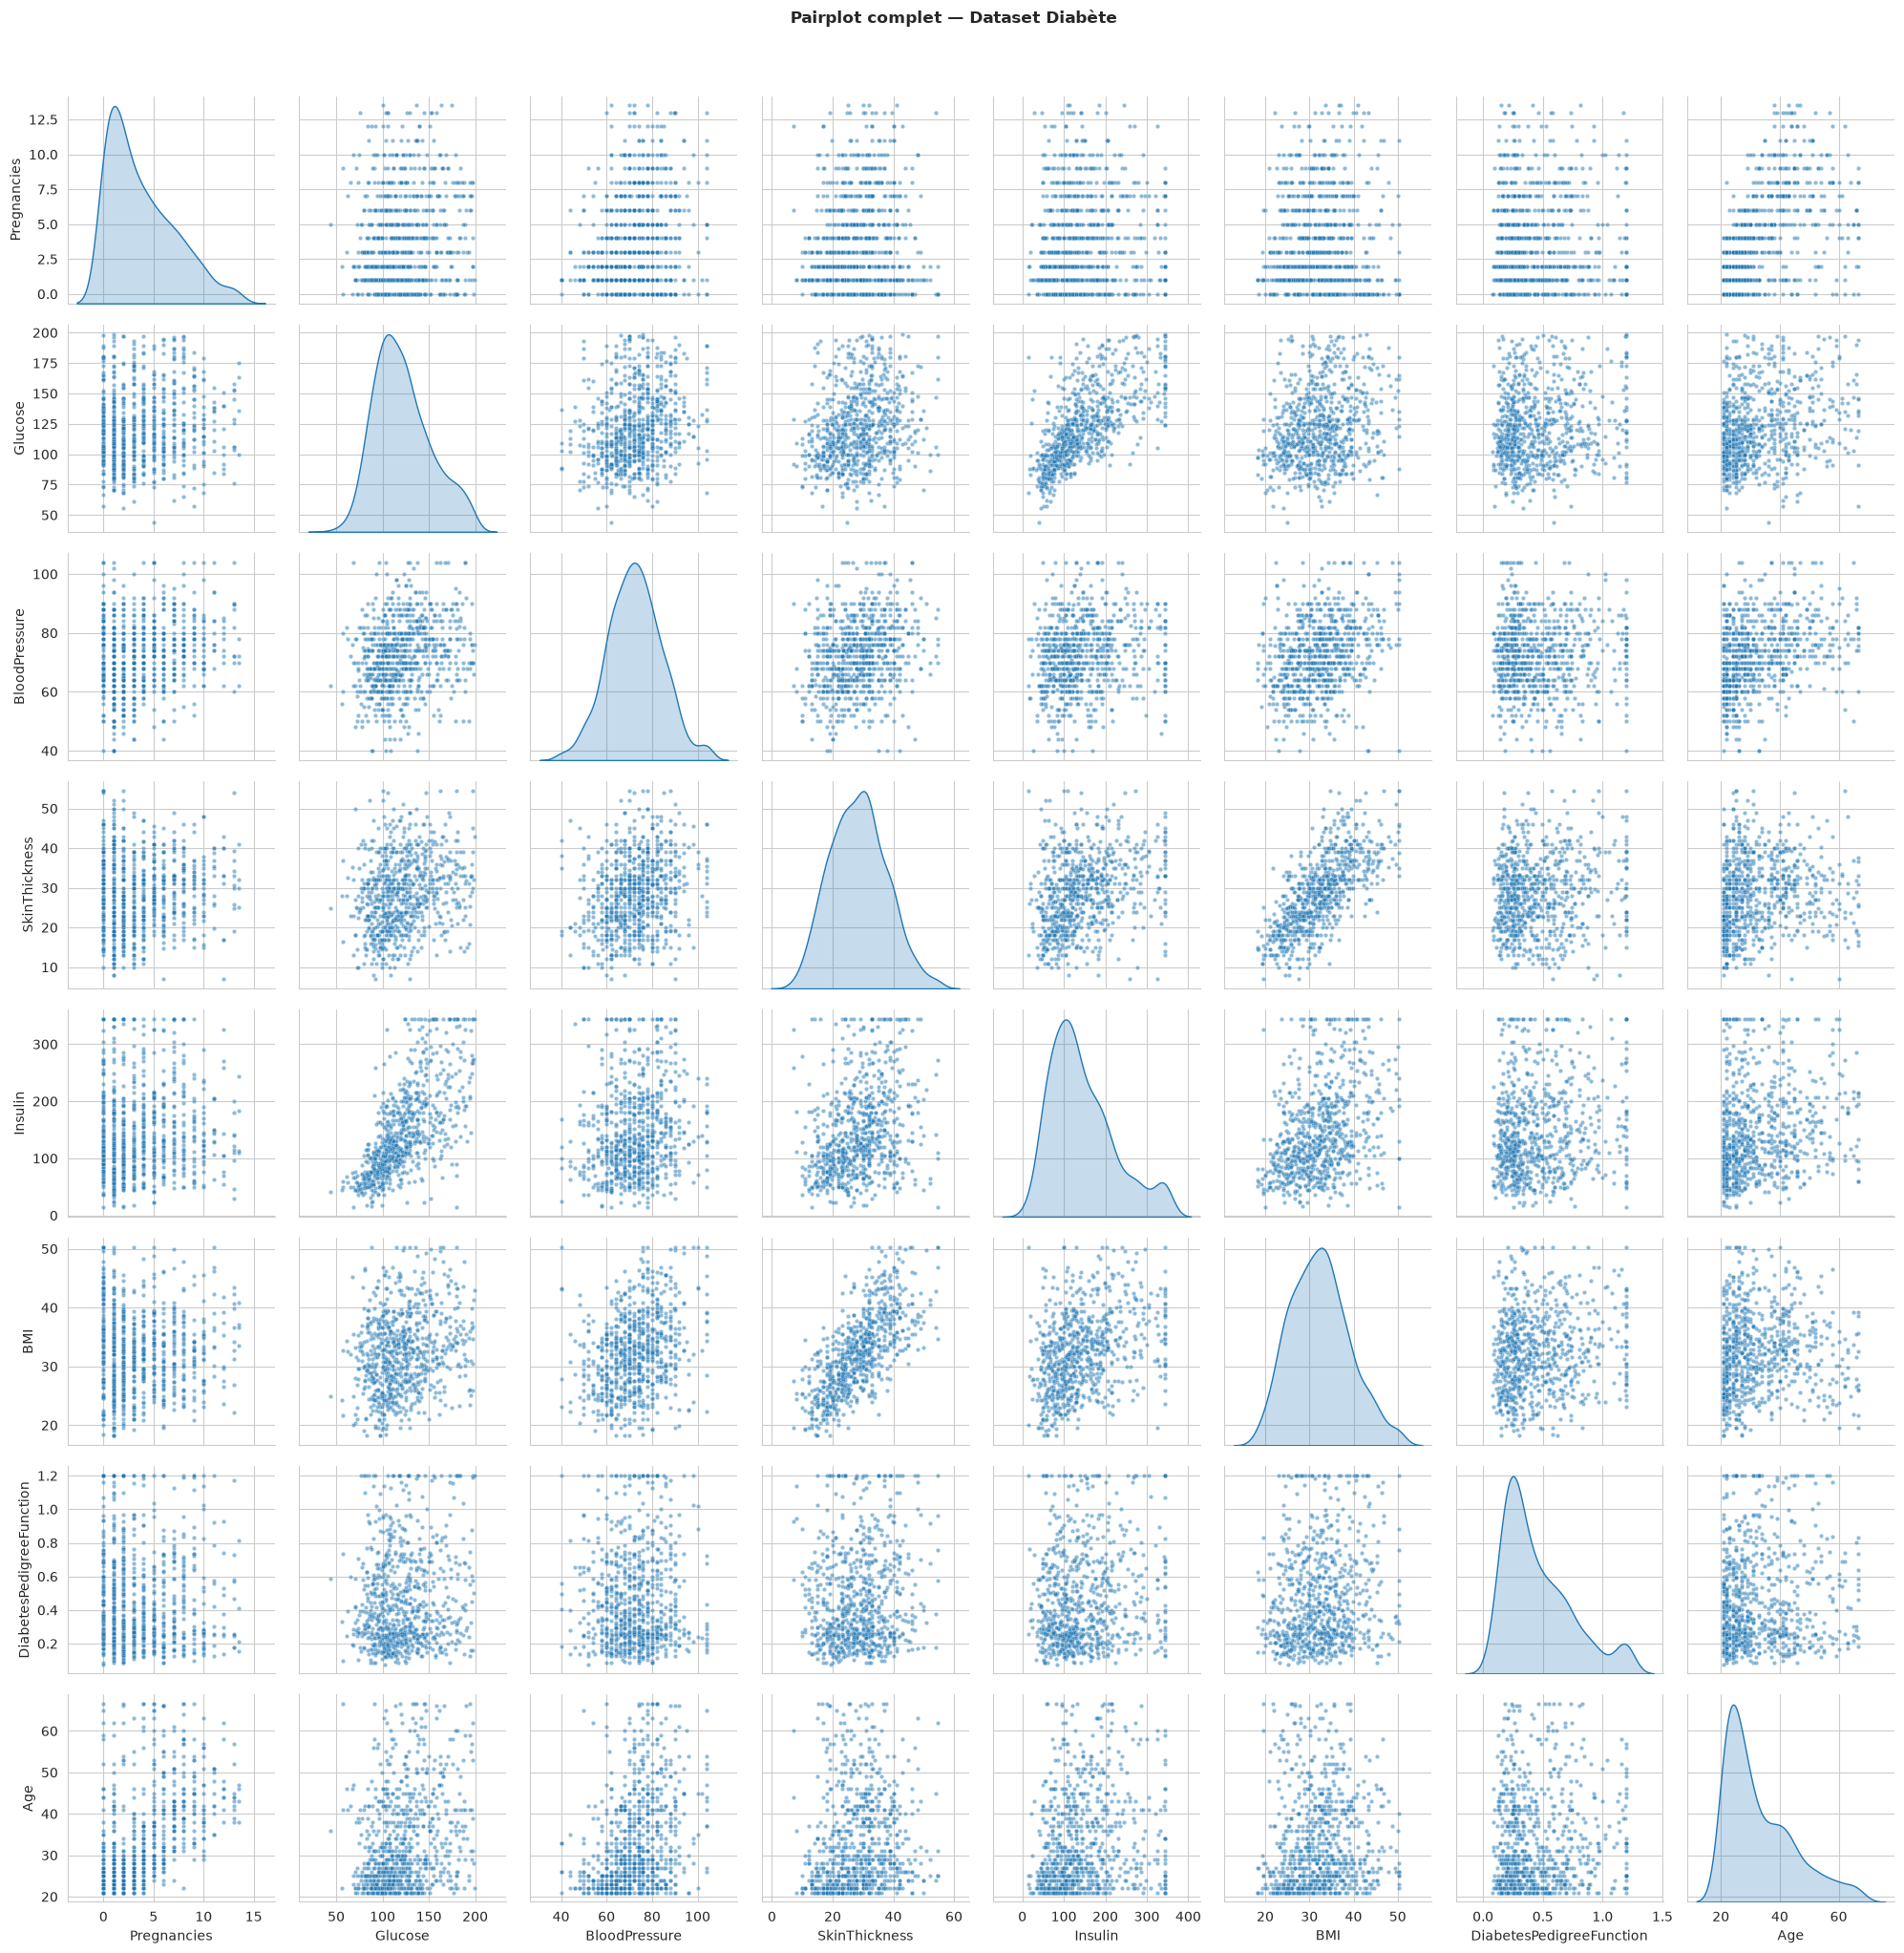

In [ ]:
# Pairplot des variables les plus variables
print(f"Pairplot des variables les plus variables : {top_variables}")
sns.pairplot(df[top_variables], diag_kind='kde')
plt.suptitle("Pairplot — Variables à forte variabilité", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot complet (toutes les variables)
print("\nPairplot complet (toutes les variables numériques) :")
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle("Pairplot complet — Dataset Diabète", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Normalisation / Standardisation

Nous appliquons le **StandardScaler** (standardisation z-score) qui transforme chaque variable pour avoir une moyenne de 0 et un écart-type de 1.

Cette étape est essentielle avant d'appliquer des algorithmes de Machine Learning sensibles aux échelles (KNN, SVM, régression logistique, etc.).

In [ ]:

scaler = StandardScaler()
colonnes_numeriques = df.select_dtypes(include='number').columns.tolist()

df_standardise = df.copy()
df_standardise[colonnes_numeriques] = scaler.fit_transform(df[colonnes_numeriques])

print("Standardisation appliquée (StandardScaler)")
print(f"\nVérification — Moyenne et écart-type après standardisation :")
stats = pd.DataFrame({
    'Moyenne': df_standardise[colonnes_numeriques].mean().round(6),
    'Écart-type': df_standardise[colonnes_numeriques].std().round(4)
})
display(stats)

print("\nAperçu des données standardisées :")
display(df_standardise.head())

✅ Standardisation appliquée (StandardScaler)

Vérification — Moyenne et écart-type après standardisation :


,Moyenne,Écart-type
Pregnancies,-0.0,1.0007
Glucose,-0.0,1.0007
BloodPressure,0.0,1.0007
SkinThickness,0.0,1.0007
Insulin,-0.0,1.0007
BMI,-0.0,1.0007
DiabetesPedigreeFunction,-0.0,1.0007
Age,0.0,1.0007



Aperçu des données standardisées :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.863399,-0.036767,0.704209,0.651174,0.183445,0.588927,1.445691
1,-0.848970,-1.206602,-0.544319,0.051424,-0.916973,-0.864347,-0.378101,-0.189304
2,1.245598,2.013400,-0.713503,-0.318488,0.935593,-1.358306,0.746595,-0.103252
3,-0.848970,-1.075174,-0.544319,-0.601361,-0.655615,-0.639820,-1.022787,-1.049828
4,-1.148194,0.501970,-2.743711,0.704209,0.292448,1.605449,2.596563,-0.017199


## 9. Export du dataset nettoyé

In [ ]:

df.to_csv("../data/dataset-diabete-nettoye.csv", index=False)
print("Dataset nettoyé exporté : ../data/dataset-diabete-nettoye.csv")
df_standardise.to_csv("../data/dataset-diabete-standardise.csv", index=False)
print(" Dataset standardisé exporté : ../data/dataset-diabete-standardise.csv")

print(f"\nRécapitulatif :")
print(f"  - Nombre de lignes : {len(df)}")
print(f"  - Nombre de colonnes : {len(df.columns)}")
print(f"  - Colonnes : {list(df.columns)}")

✅ Dataset nettoyé exporté : ../data/dataset-diabete-nettoye.csv
✅ Dataset standardisé exporté : ../data/dataset-diabete-standardise.csv

Récapitulatif :
  - Nombre de lignes : 768
  - Nombre de colonnes : 8
  - Colonnes : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
